# Credit Risk PD Modeling and Scoring Pipeline

This project develops a probability-of-default model for consumer credit risk assessment. The target variable, `SeriousDlqin2yrs`, indicates whether a borrower experienced 90 or more days past-due delinquency within two years.

The workflow covers data exploration, preprocessing, model training, probability calibration, threshold selection, and final evaluation. The goal is to rank borrowers by default risk and support credit decisioning with interpretable performance metrics.


## Executive Summary

This project estimates borrower default risk using a structured tabular dataset. The final workflow uses leakage-safe preprocessing, model comparison with metrics suitable for class imbalance, probability calibration, cost-sensitive threshold selection, lift analysis, and model interpretation.

At a high level, the final recommendation is expected to favor a tree-based gradient boosting model because it captures nonlinear relationships and interactions while maintaining strong ranking performance. Logistic Regression is retained as an interpretable benchmark, Random Forest is retained as a nonlinear benchmark, and DummyClassifier is included as a sanity-check baseline.

The final recommendation is based on validation PR-AUC for model selection, calibrated probability quality for PD interpretation, and held-out test performance for final reporting.


# Business Understanding

This stage defines the credit-risk objective, the target event, and the intended decision-support use case.


## 1. Project Setup

The data files are stored locally in this repository, so the workflow reads `data/credit_risk_data.csv` directly. This setup keeps the analysis reproducible and avoids external data-access dependencies.

The modeling workflow uses sklearn-native tools for preprocessing, model training, calibration, and evaluation. SHAP is used for model interpretation.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
DATA_PATH = "data/credit_risk_data.csv"
TARGET = "SeriousDlqin2yrs"
ID_COL = "Unnamed: 0"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Data Dictionary

The project data dictionary is summarized below so the notebook remains self-contained. The target is a serious delinquency event, so the positive class is `SeriousDlqin2yrs = 1`.

| Variable | Description | Type |
|---|---|---|
| `SeriousDlqin2yrs` | Person experienced 90 days past due delinquency or worse | Y/N |
| `RevolvingUtilizationOfUnsecuredLines` | Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by credit limits | percentage |
| `age` | Age of borrower in years | integer |
| `NumberOfTime30-59DaysPastDueNotWorse` | Number of times borrower has been 30-59 days past due but no worse in the last 2 years | integer |
| `DebtRatio` | Monthly debt payments, alimony, living costs divided by monthly gross income | percentage |
| `MonthlyIncome` | Monthly income | real |
| `NumberOfOpenCreditLinesAndLoans` | Number of open loans and lines of credit | integer |
| `NumberOfTimes90DaysLate` | Number of times borrower has been 90 days or more past due | integer |
| `NumberRealEstateLoansOrLines` | Number of mortgage and real-estate loans including home equity lines of credit | integer |
| `NumberOfTime60-89DaysPastDueNotWorse` | Number of times borrower has been 60-89 days past due but no worse in the last 2 years | integer |
| `NumberOfDependents` | Number of dependents in family excluding themselves | integer |


In [2]:
FEATURE_DEFINITIONS = {
    "SeriousDlqin2yrs": "Target: borrower experienced 90+ days past due delinquency or worse within two years.",
    "RevolvingUtilizationOfUnsecuredLines": "Unsecured revolving balance divided by credit limits.",
    "age": "Borrower age in years.",
    "NumberOfTime30-59DaysPastDueNotWorse": "30-59 day past-due count in the last two years.",
    "DebtRatio": "Monthly debt payments, alimony, and living costs divided by monthly gross income.",
    "MonthlyIncome": "Monthly income.",
    "NumberOfOpenCreditLinesAndLoans": "Number of open installment loans and credit lines.",
    "NumberOfTimes90DaysLate": "90+ day past-due count.",
    "NumberRealEstateLoansOrLines": "Number of mortgage and real-estate loans, including home equity lines.",
    "NumberOfTime60-89DaysPastDueNotWorse": "60-89 day past-due count in the last two years.",
    "NumberOfDependents": "Number of dependents in family, excluding the borrower.",
}


# Data Understanding

This stage examines the dataset structure, target imbalance, missingness, and early risk patterns.


## 3. Load and Inspect Data

This section checks the raw dataset size, data types, missing values, and class balance. These checks determine the modeling strategy: missing income/dependents require imputation, and the low default rate requires imbalanced-class evaluation metrics.


In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()


Rows: 150,000
Columns: 12


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.7661,45,2,0.8030,"9,120.0000",13,0,6,0,2.0000
1,2,0,0.9572,40,0,0.1219,"2,600.0000",4,0,0,0,1.0000
2,3,0,0.6582,38,1,0.0851,"3,042.0000",2,1,0,0,0.0000
3,4,0,0.2338,30,0,0.0360,"3,300.0000",5,0,0,0,0.0000
4,5,0,0.9072,49,1,0.0249,"63,588.0000",7,0,1,0,0.0000


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [5]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean(),
}).sort_values("missing_rate", ascending=False)
missing_summary


,missing_count,missing_rate
MonthlyIncome,29731,0.1982
NumberOfDependents,3924,0.0262
Unnamed: 0,0,0.0000
SeriousDlqin2yrs,0,0.0000
RevolvingUtilizationOfUnsecuredLines,0,0.0000
age,0,0.0000
NumberOfTime30-59DaysPastDueNotWorse,0,0.0000
DebtRatio,0,0.0000
NumberOfOpenCreditLinesAndLoans,0,0.0000
NumberOfTimes90DaysLate,0,0.0000


In [6]:
target_distribution = pd.DataFrame({
    "count": df[TARGET].value_counts().sort_index(),
    "rate": df[TARGET].value_counts(normalize=True).sort_index(),
})
target_distribution


,count,rate
SeriousDlqin2yrs,,
0,139974,0.9332
1,10026,0.0668


## 4. Exploratory Data Analysis

EDA is used here to understand risk signal and data quality, not to manually overfit rules. The main checks are feature distributions, default/non-default median differences, and missing-value behavior.


In [7]:
feature_cols = [c for c in df.columns if c not in [ID_COL, TARGET]]
df[feature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,"150,000.0000",6.0484,249.7554,0.0000,0.0299,0.1542,0.5590,"50,708.0000"
age,"150,000.0000",52.2952,14.7719,0.0000,41.0000,52.0000,63.0000,109.0000
NumberOfTime30-59DaysPastDueNotWorse,"150,000.0000",0.4210,4.1928,0.0000,0.0000,0.0000,0.0000,98.0000
DebtRatio,"150,000.0000",353.0051,"2,037.8185",0.0000,0.1751,0.3665,0.8683,"329,664.0000"
MonthlyIncome,"120,269.0000","6,670.2212","14,384.6742",0.0000,"3,400.0000","5,400.0000","8,249.0000","3,008,750.0000"
NumberOfOpenCreditLinesAndLoans,"150,000.0000",8.4528,5.1460,0.0000,5.0000,8.0000,11.0000,58.0000
NumberOfTimes90DaysLate,"150,000.0000",0.2660,4.1693,0.0000,0.0000,0.0000,0.0000,98.0000
NumberRealEstateLoansOrLines,"150,000.0000",1.0182,1.1298,0.0000,0.0000,1.0000,2.0000,54.0000
NumberOfTime60-89DaysPastDueNotWorse,"150,000.0000",0.2404,4.1552,0.0000,0.0000,0.0000,0.0000,98.0000
NumberOfDependents,"146,076.0000",0.7572,1.1151,0.0000,0.0000,0.0000,1.0000,20.0000


In [8]:
group_medians = df.groupby(TARGET)[feature_cols].median().T
group_medians.columns = ["non_default_median", "default_median"]
group_medians["default_minus_non_default"] = group_medians["default_median"] - group_medians["non_default_median"]
group_medians.sort_values("default_minus_non_default", ascending=False)


,non_default_median,default_median,default_minus_non_default
RevolvingUtilizationOfUnsecuredLines,0.1333,0.8389,0.7056
DebtRatio,0.3627,0.4282,0.0656
NumberOfTime30-59DaysPastDueNotWorse,0.0000,0.0000,0.0000
NumberOfTimes90DaysLate,0.0000,0.0000,0.0000
NumberRealEstateLoansOrLines,1.0000,1.0000,0.0000
NumberOfTime60-89DaysPastDueNotWorse,0.0000,0.0000,0.0000
NumberOfDependents,0.0000,0.0000,0.0000
NumberOfOpenCreditLinesAndLoans,8.0000,7.0000,-1.0000
age,52.0000,45.0000,-7.0000
MonthlyIncome,"5,466.0000","4,500.0000",-966.0000


In [9]:
missing_risk = pd.DataFrame({
    "group": ["MonthlyIncome observed", "MonthlyIncome missing", "NumberOfDependents observed", "NumberOfDependents missing"],
    "default_rate": [
        df.loc[df["MonthlyIncome"].notna(), TARGET].mean(),
        df.loc[df["MonthlyIncome"].isna(), TARGET].mean(),
        df.loc[df["NumberOfDependents"].notna(), TARGET].mean(),
        df.loc[df["NumberOfDependents"].isna(), TARGET].mean(),
    ],
    "borrowers": [
        df["MonthlyIncome"].notna().sum(),
        df["MonthlyIncome"].isna().sum(),
        df["NumberOfDependents"].notna().sum(),
        df["NumberOfDependents"].isna().sum(),
    ],
})
missing_risk


,group,default_rate,borrowers
0,MonthlyIncome observed,0.0695,120269
1,MonthlyIncome missing,0.0561,29731
2,NumberOfDependents observed,0.0674,146076
3,NumberOfDependents missing,0.0456,3924


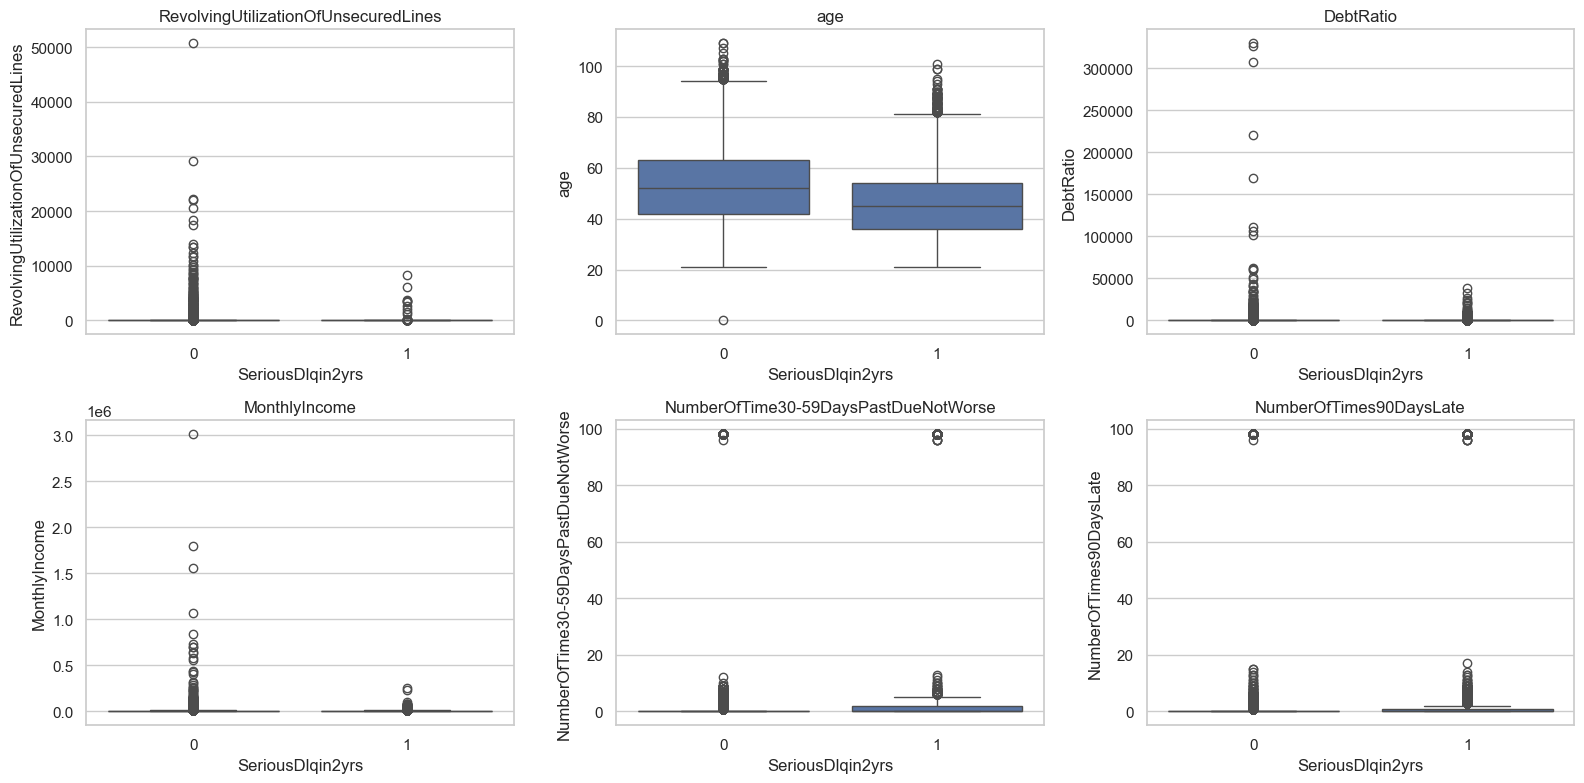

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for ax, col in zip(axes.flatten(), plot_cols):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()


## 5. Modeling Strategy

The modeling strategy is designed around the characteristics of the default prediction problem: rare positive events, skewed financial variables, missing borrower attributes, and the need for interpretable risk-ranking outputs.

The workflow uses the following design choices:

- The data is split before preprocessing to avoid leakage.
- Preprocessing is fit inside sklearn pipelines.
- Model selection uses PR-AUC rather than accuracy because only a small share of borrowers default.
- Candidate models include an interpretable linear benchmark and nonlinear tree-based models suitable for tabular credit-risk data.
- Model selection, probability calibration, threshold selection, and final testing are performed on separate samples.

The candidate models are:

- `DummyClassifier`: sanity-check baseline.
- Balanced `LogisticRegression`: interpretable linear benchmark.
- Balanced `RandomForestClassifier`: nonlinear tree ensemble benchmark.
- Balanced `HistGradientBoostingClassifier`: sklearn-native gradient boosting model for tabular data.


In [11]:
model_df = df.copy()
model_df = model_df[model_df["age"] >= 18].copy()

X = model_df.drop(columns=[ID_COL, TARGET])
y = model_df[TARGET]

X_train_valid_policy, X_test, y_train_valid_policy, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_train_valid_policy,
    y_train_valid_policy,
    test_size=0.40,
    stratify=y_train_valid_policy,
    random_state=RANDOM_STATE,
)

X_valid, X_policy, y_valid, y_policy = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print(f"Train:            {X_train.shape[0]:,} rows")
print(f"Model validation: {X_valid.shape[0]:,} rows")
print(f"Calibration/policy:{X_policy.shape[0]:,} rows")
print(f"Test:             {X_test.shape[0]:,} rows")
print("\nDefault rates:")
print(pd.Series({
    "train": y_train.mean(),
    "model_validation": y_valid.mean(),
    "calibration_policy": y_policy.mean(),
    "test": y_test.mean(),
}))


Train:            67,499 rows
Model validation: 22,500 rows
Calibration/policy:22,500 rows
Test:             37,500 rows

Default rates:
train                0.0668
model_validation     0.0668
calibration_policy   0.0668
test                 0.0669
dtype: float64


# Data Preparation and Feature Engineering

This stage converts raw borrower variables into a leakage-safe modeling matrix and adds credit-risk-oriented predictors.


## 6. Leakage-Safe Preprocessing and Credit-Risk Features

The custom transformer learns medians and winsorization caps only from the training data passed to `fit`. It also adds credit-risk-oriented features that summarize delinquency and affordability signals:

- `DelinquencyCountTotal`: total 30-59, 60-89, and 90+ day delinquency count.
- `AnyDelinquency`: whether the borrower has any delinquency history in the lookback window.
- `SevereDelinquency`: whether the borrower has any 90+ day delinquency.
- `LogMonthlyIncome`: log-transformed income for skew control.
- `DebtPerIncome`: approximate monthly debt amount derived from debt ratio and income.
- `CreditPerProperty`: credit lines relative to real-estate loan count.
- Missing indicators for income and dependents.


In [12]:
class CreditRiskPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, add_engineered_features=True):
        self.add_engineered_features = add_engineered_features
        self.median_cols = ["MonthlyIncome", "NumberOfDependents"]
        self.winsor_cols = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]
        self.upper_clip_values = {
            "NumberOfTime30-59DaysPastDueNotWorse": 10,
            "NumberOfTime60-89DaysPastDueNotWorse": 10,
            "NumberOfTimes90DaysLate": 10,
            "NumberRealEstateLoansOrLines": 5,
        }

    def fit(self, X, y=None):
        X = X.copy()
        self.feature_names_in_ = list(X.columns)
        self.medians_ = {col: X[col].median() for col in self.median_cols}
        self.winsor_bounds_ = {
            col: (X[col].quantile(0.01), X[col].quantile(0.99))
            for col in self.winsor_cols
        }
        transformed = self._transform_frame(X)
        self.feature_names_out_ = list(transformed.columns)
        return self

    def transform(self, X):
        return self._transform_frame(X.copy())

    def _transform_frame(self, X):
        X = X[self.feature_names_in_].copy()

        X["MonthlyIncome_missing"] = X["MonthlyIncome"].isna().astype(int)
        X["NumberOfDependents_missing"] = X["NumberOfDependents"].isna().astype(int)

        for col, median_value in self.medians_.items():
            X[col] = X[col].fillna(median_value)

        for col, (lower, upper) in self.winsor_bounds_.items():
            X[col] = X[col].clip(lower=lower, upper=upper)

        for col, upper in self.upper_clip_values.items():
            X[col] = X[col].clip(upper=upper)

        if self.add_engineered_features:
            delinquency_cols = [
                "NumberOfTime30-59DaysPastDueNotWorse",
                "NumberOfTime60-89DaysPastDueNotWorse",
                "NumberOfTimes90DaysLate",
            ]
            X["DelinquencyCountTotal"] = X[delinquency_cols].sum(axis=1)
            X["AnyDelinquency"] = (X["DelinquencyCountTotal"] > 0).astype(int)
            X["SevereDelinquency"] = (X["NumberOfTimes90DaysLate"] > 0).astype(int)
            X["LogMonthlyIncome"] = np.log1p(X["MonthlyIncome"].clip(lower=0))
            X["DebtPerIncome"] = X["DebtRatio"] * X["MonthlyIncome"]
            X["CreditPerProperty"] = X["NumberOfOpenCreditLinesAndLoans"] / (X["NumberRealEstateLoansOrLines"] + 1)
            X["UtilizationOverOne"] = (X["RevolvingUtilizationOfUnsecuredLines"] > 1).astype(int)

        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)


In [13]:
preprocessor_check = CreditRiskPreprocessor().fit(X_train)
preprocessor_check.transform(X_train).head()


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing,DelinquencyCountTotal,AnyDelinquency,SevereDelinquency,LogMonthlyIncome,DebtPerIncome,CreditPerProperty,UtilizationOverOne
69082,0.6384,31,1,0.7955,"3,705.0000",16,0,2,0,0.0000,0,0,1,1,0,8.2177,"2,947.2045",5.3333,0
87952,0.6362,52,0,0.1083,"12,335.0000",4,0,0,0,0.0000,0,0,0,0,0,9.4203,"1,335.8917",4.0000,0
52313,0.0000,50,0,"1,068.0000","5,400.0000",12,0,0,0,0.0000,1,0,0,0,0,8.5943,"5,767,200.0000",12.0000,0
45245,0.2173,73,0,0.2207,"6,134.0000",9,0,0,0,1.0000,0,0,0,0,0,8.7218,"1,353.7793",9.0000,0
44373,0.1989,74,0,0.0576,"3,400.0000",3,0,0,0,0.0000,0,0,0,0,0,8.1318,195.9424,3.0000,0


# Modeling

This stage trains and compares candidate models using metrics appropriate for rare default events.


## 7. Model Training and Hyperparameter Search

Models are tuned using cross-validated PR-AUC (`average_precision`). PR-AUC is more informative than accuracy in rare-event classification because it focuses on the positive default class.


In [14]:
models = {
    "Dummy": {
        "pipeline": Pipeline([
            ("prep", CreditRiskPreprocessor()),
            ("model", DummyClassifier(strategy="prior", random_state=RANDOM_STATE)),
        ]),
        "params": {},
    },
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("prep", CreditRiskPreprocessor()),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                solver="liblinear",
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            )),
        ]),
        "params": {
            "model__penalty": ["l1", "l2"],
            "model__C": [0.01, 0.1, 1.0],
        },
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("prep", CreditRiskPreprocessor()),
            ("model", RandomForestClassifier(
                n_estimators=150,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ]),
        "params": {
            "model__max_depth": [5, 10],
            "model__min_samples_leaf": [25, 75],
        },
    },
    "HistGradientBoosting": {
        "pipeline": Pipeline([
            ("prep", CreditRiskPreprocessor()),
            ("model", HistGradientBoostingClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
        "params": {
            "model__learning_rate": [0.05, 0.1],
            "model__max_leaf_nodes": [15, 31],
            "model__l2_regularization": [0.0, 0.1],
        },
    },
}


In [15]:
best_models = {}
search_results = []

for name, spec in models.items():
    if spec["params"]:
        search = GridSearchCV(
            estimator=spec["pipeline"],
            param_grid=spec["params"],
            scoring="average_precision",
            cv=3,
            n_jobs=-1,
        )
        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
        search_results.append({
            "model": name,
            "best_cv_pr_auc": search.best_score_,
            "best_params": search.best_params_,
        })
    else:
        spec["pipeline"].fit(X_train, y_train)
        best_models[name] = spec["pipeline"]
        search_results.append({"model": name, "best_cv_pr_auc": np.nan, "best_params": {}})

pd.DataFrame(search_results)


,model,best_cv_pr_auc,best_params
0,Dummy,NaN,{}
1,Logistic Regression,0.3714,"{'model__C': 0.01, 'model__penalty': 'l2'}"
2,Random Forest,0.3887,"{'model__max_depth': 10, 'model__min_samples_l..."
3,HistGradientBoosting,0.3918,"{'model__l2_regularization': 0.0, 'model__lear..."


## 8. Validation Model Comparison and Recommendation

The validation set compares candidate models before the test set is used. The preferred model should have strong PR-AUC and ROC-AUC, acceptable probability behavior, and a practical balance between interpretability and performance.

The recommendation is based primarily on validation PR-AUC because the goal is to rank and identify rare default cases.


In [16]:
def model_scores(model, X_eval, y_eval, threshold=0.5):
    y_score = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_score >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_eval, y_score),
        "pr_auc": average_precision_score(y_eval, y_score),
        "brier": brier_score_loss(y_eval, y_score),
        "precision_at_0_5": precision_score(y_eval, y_pred, zero_division=0),
        "recall_at_0_5": recall_score(y_eval, y_pred, zero_division=0),
        "f1_at_0_5": f1_score(y_eval, y_pred, zero_division=0),
    }

validation_results = pd.DataFrame([
    {"model": name, **model_scores(model, X_valid, y_valid)}
    for name, model in best_models.items()
]).sort_values("pr_auc", ascending=False)

validation_results


,model,roc_auc,pr_auc,brier,precision_at_0_5,recall_at_0_5,f1_at_0_5
2,Random Forest,0.8613,0.3940,0.1253,0.2444,0.7214,0.3651
3,HistGradientBoosting,0.8610,0.3880,0.1391,0.2169,0.7580,0.3373
1,Logistic Regression,0.8553,0.3778,0.1464,0.2146,0.7380,0.3325
0,Dummy,0.5000,0.0668,0.0624,0.0000,0.0000,0.0000


In [17]:
selected_model_name = validation_results.iloc[0]["model"]
selected_model = best_models[selected_model_name]

runner_up = validation_results.iloc[1]
selected_pr_auc = float(validation_results.iloc[0]["pr_auc"])
runner_up_pr_auc = float(runner_up["pr_auc"])

model_recommendation = pd.DataFrame([{
    "recommended_model": selected_model_name,
    "reason": (
        "Highest validation PR-AUC among candidate models, with a small but positive margin over "
        f"{runner_up['model']} ({selected_pr_auc:.4f} vs {runner_up_pr_auc:.4f}). "
        "The selected model also supports nonlinear borrower-risk patterns and is later calibrated before policy use."
    ),
    "benchmark_note": (
        "Logistic Regression remains useful as an interpretable benchmark, but the selected model provides stronger "
        "minority-class ranking performance on the validation set."
    ),
}])
model_recommendation

,recommended_model,reason,benchmark_note
0,Random Forest,Highest validation PR-AUC among candidate mode...,Logistic Regression remains useful as an inter...


# Evaluation and Policy Selection

This stage evaluates model ranking, calibrates probability estimates, selects a decision threshold, and reports final test performance.


## 9. Probability Calibration

A credit-risk model is more useful when predicted scores can be interpreted as approximate probabilities of default. This section calibrates the selected model on a separate calibration/policy set using isotonic calibration. This prevents the model-selection validation set from also being used for calibration and threshold policy decisions.


In [18]:
calibrated_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(selected_model),
    method="isotonic",
)
calibrated_model.fit(X_policy, y_policy)

uncalibrated_policy_score = selected_model.predict_proba(X_policy)[:, 1]
calibrated_policy_score = calibrated_model.predict_proba(X_policy)[:, 1]

calibration_comparison = pd.DataFrame([
    {
        "score_version": "uncalibrated",
        "roc_auc": roc_auc_score(y_policy, uncalibrated_policy_score),
        "pr_auc": average_precision_score(y_policy, uncalibrated_policy_score),
        "brier": brier_score_loss(y_policy, uncalibrated_policy_score),
    },
    {
        "score_version": "calibrated_isotonic",
        "roc_auc": roc_auc_score(y_policy, calibrated_policy_score),
        "pr_auc": average_precision_score(y_policy, calibrated_policy_score),
        "brier": brier_score_loss(y_policy, calibrated_policy_score),
    },
])
calibration_comparison


,score_version,roc_auc,pr_auc,brier
0,uncalibrated,0.8684,0.4069,0.1258
1,calibrated_isotonic,0.8703,0.3964,0.0485


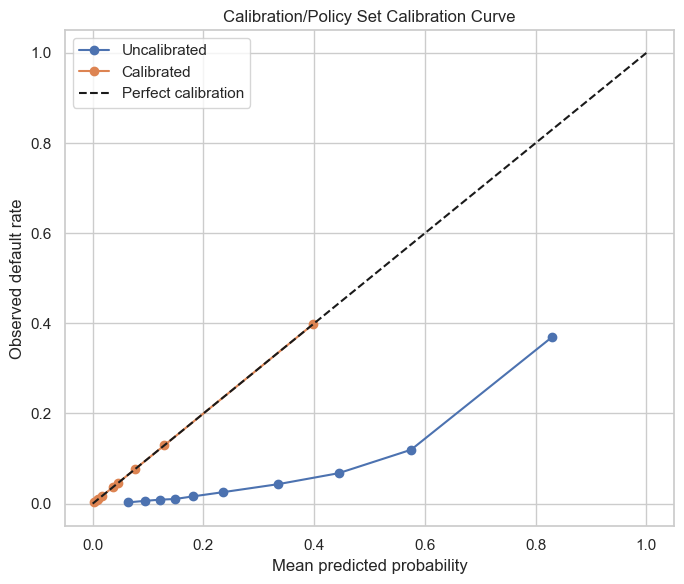

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))

for label, scores in [("Uncalibrated", uncalibrated_policy_score), ("Calibrated", calibrated_policy_score)]:
    prob_true, prob_pred = calibration_curve(y_policy, scores, n_bins=10, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", label=label)

ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_title("Calibration/Policy Set Calibration Curve")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.legend()
plt.tight_layout()


## 10. Cost-Sensitive Threshold Selection

A PD model produces a score; a lending policy still needs a cutoff. The correct threshold depends on business costs. This project uses the separate calibration/policy set to choose the threshold, after model selection has already been completed.

The illustrative cost setup treats a false negative as 10 times as costly as a false positive:

- False negative: a defaulting borrower is not flagged as high risk.
- False positive: a non-defaulting borrower is flagged for rejection or manual review.

This assumption is not meant to be universal. In a production lending setting, the threshold should be tied to expected loss and operating economics, including exposure at default, loss given default, interest income, funding cost, manual-review capacity, and customer/approval trade-offs. The sensitivity analysis below shows how the selected threshold changes under different false-negative costs.

In [20]:
def threshold_table_from_scores(y_true, y_score, false_negative_cost=10, false_positive_cost=1, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.01, 1.00, 0.01)
    rows = []
    n = len(y_true)
    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        expected_cost = fp * false_positive_cost + fn * false_negative_cost
        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "flagged_rate": y_pred.mean(),
            "expected_cost_per_1000": expected_cost / n * 1000,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        })
    return pd.DataFrame(rows)

policy_thresholds = threshold_table_from_scores(y_policy, calibrated_policy_score, false_negative_cost=10)
policy_thresholds.iloc[::5].head(20)


,threshold,precision,recall,f1,flagged_rate,expected_cost_per_1000,tp,fp,fn,tn
0,0.0100,0.0874,0.9827,0.1605,0.7518,697.6444,1478,15437,26,5559
5,0.0600,0.2039,0.8072,0.3255,0.2647,339.6000,1214,4741,290,16255
10,0.1100,0.2712,0.6882,0.3891,0.1696,332.0444,1035,2781,469,18215
15,0.1600,0.3456,0.5878,0.4353,0.1137,349.9556,884,1674,620,19322
20,0.2100,0.3978,0.5140,0.4485,0.0864,376.8889,773,1170,731,19826
25,0.2600,0.4352,0.4508,0.4428,0.0692,406.2222,678,880,826,20116
30,0.3100,0.4467,0.4322,0.4393,0.0647,415.3333,650,805,854,20191
35,0.3600,0.5437,0.2733,0.3637,0.0336,501.1111,411,345,1093,20651
40,0.4100,0.5437,0.2733,0.3637,0.0336,501.1111,411,345,1093,20651
45,0.4600,0.6580,0.1676,0.2671,0.0170,562.2667,252,131,1252,20865


In [21]:
cost_sensitivity_rows = []
for fn_cost in [3, 5, 10, 20]:
    table = threshold_table_from_scores(y_policy, calibrated_policy_score, false_negative_cost=fn_cost)
    best_row = table.sort_values("expected_cost_per_1000", ascending=True).iloc[0]
    cost_sensitivity_rows.append({
        "false_negative_cost": fn_cost,
        "false_positive_cost": 1,
        "selected_threshold": best_row["threshold"],
        "precision": best_row["precision"],
        "recall": best_row["recall"],
        "flagged_rate": best_row["flagged_rate"],
        "expected_cost_per_1000": best_row["expected_cost_per_1000"],
    })

cost_sensitivity = pd.DataFrame(cost_sensitivity_rows)
cost_sensitivity


,false_negative_cost,false_positive_cost,selected_threshold,precision,recall,flagged_rate,expected_cost_per_1000
0,3,1,0.2600,0.4352,0.4508,0.0692,149.2444
1,5,1,0.1900,0.3667,0.5585,0.1018,212.0444
2,10,1,0.0900,0.2470,0.7294,0.1974,329.5111
3,20,1,0.0500,0.1812,0.8418,0.3105,465.8222


In [22]:
best_cost_row = policy_thresholds.sort_values("expected_cost_per_1000", ascending=True).iloc[0]
best_f1_row = policy_thresholds.sort_values("f1", ascending=False).iloc[0]

threshold_selection_summary = pd.DataFrame([
    {"selection_rule": "minimum_expected_cost_FN10_FP1", **best_cost_row.to_dict()},
    {"selection_rule": "maximum_f1", **best_f1_row.to_dict()},
])

selected_threshold = float(best_cost_row["threshold"])
threshold_selection_summary


,selection_rule,threshold,precision,recall,f1,flagged_rate,expected_cost_per_1000,tp,fp,fn,tn
0,minimum_expected_cost_FN10_FP1,0.0900,0.2470,0.7294,0.3690,0.1974,329.5111,"1,097.0000","3,344.0000",407.0000,"17,652.0000"
1,maximum_f1,0.2300,0.3978,0.5140,0.4485,0.0864,376.8889,773.0000,"1,170.0000",731.0000,"19,826.0000"


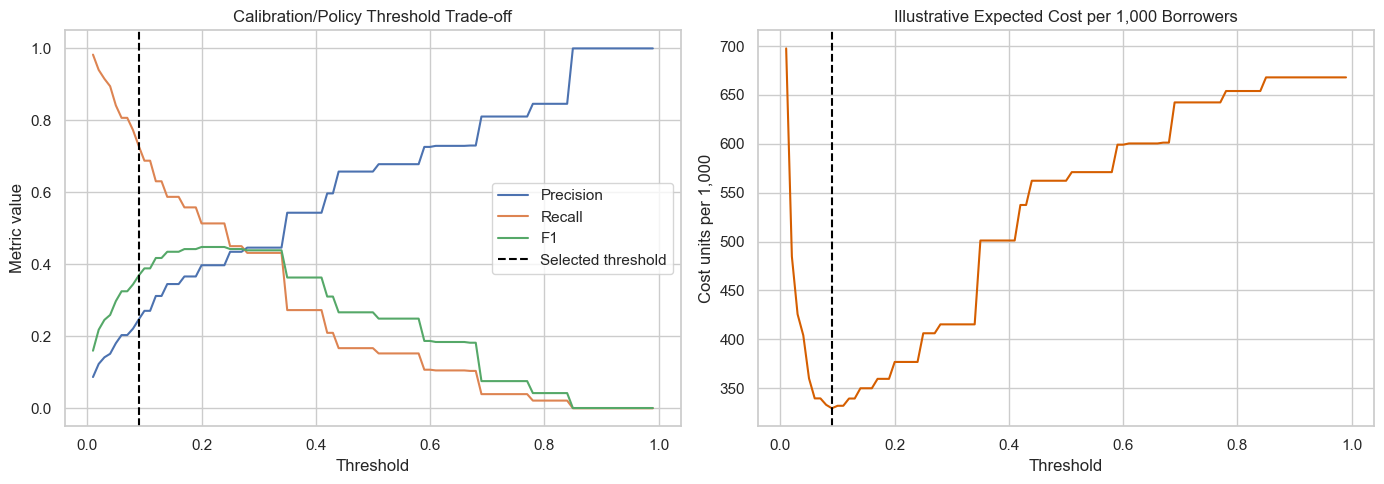

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(policy_thresholds["threshold"], policy_thresholds["precision"], label="Precision")
axes[0].plot(policy_thresholds["threshold"], policy_thresholds["recall"], label="Recall")
axes[0].plot(policy_thresholds["threshold"], policy_thresholds["f1"], label="F1")
axes[0].axvline(selected_threshold, color="black", linestyle="--", label="Selected threshold")
axes[0].set_title("Calibration/Policy Threshold Trade-off")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Metric value")
axes[0].legend()

axes[1].plot(policy_thresholds["threshold"], policy_thresholds["expected_cost_per_1000"], color="#D55E00")
axes[1].axvline(selected_threshold, color="black", linestyle="--")
axes[1].set_title("Illustrative Expected Cost per 1,000 Borrowers")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Cost units per 1,000")

plt.tight_layout()


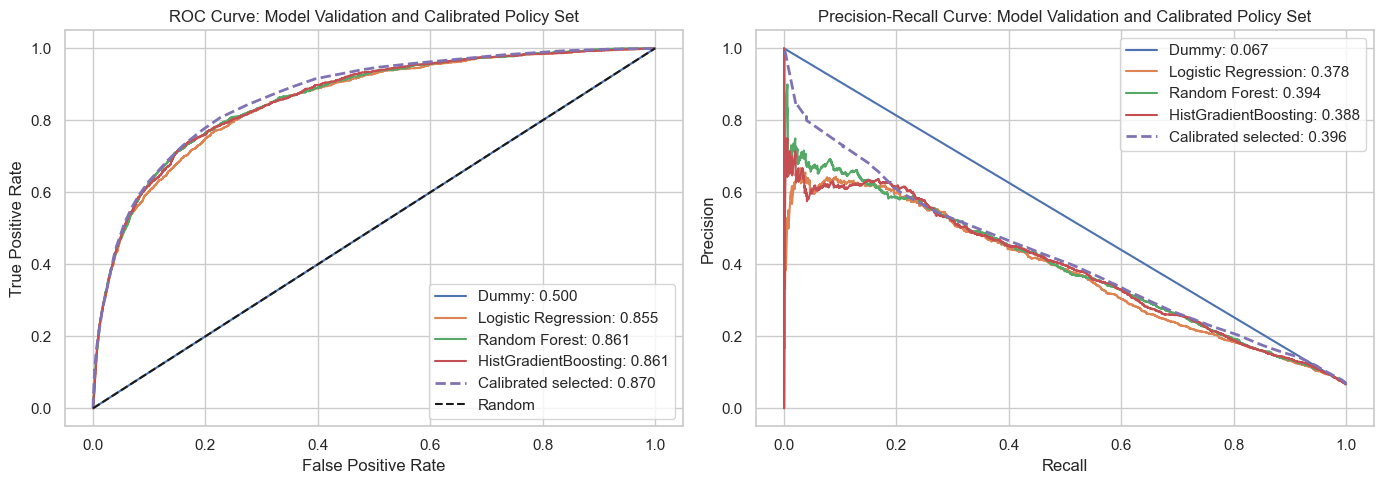

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in best_models.items():
    y_score = model.predict_proba(X_valid)[:, 1]
    fpr, tpr, _ = roc_curve(y_valid, y_score)
    axes[0].plot(fpr, tpr, label=f"{name}: {roc_auc_score(y_valid, y_score):.3f}")

policy_fpr, policy_tpr, _ = roc_curve(y_policy, calibrated_policy_score)
axes[0].plot(policy_fpr, policy_tpr, linestyle="--", linewidth=2, label=f"Calibrated selected: {roc_auc_score(y_policy, calibrated_policy_score):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curve: Model Validation and Calibrated Policy Set")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

for name, model in best_models.items():
    y_score = model.predict_proba(X_valid)[:, 1]
    precision, recall, _ = precision_recall_curve(y_valid, y_score)
    axes[1].plot(recall, precision, label=f"{name}: {average_precision_score(y_valid, y_score):.3f}")

policy_precision, policy_recall, _ = precision_recall_curve(y_policy, calibrated_policy_score)
axes[1].plot(policy_recall, policy_precision, linestyle="--", linewidth=2, label=f"Calibrated selected: {average_precision_score(y_policy, calibrated_policy_score):.3f}")
axes[1].set_title("Precision-Recall Curve: Model Validation and Calibrated Policy Set")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()


## 11. Final Test Evaluation

The test set is used only after model selection, calibration, and threshold selection. This gives the cleanest estimate of out-of-sample performance in this notebook.


In [25]:
test_score = calibrated_model.predict_proba(X_test)[:, 1]
test_pred = (test_score >= selected_threshold).astype(int)

test_metrics = pd.DataFrame([{
    "selected_model": selected_model_name,
    "probability_version": "isotonic_calibrated",
    "threshold_rule": "minimum_expected_cost_FN10_FP1",
    "threshold": selected_threshold,
    "roc_auc": roc_auc_score(y_test, test_score),
    "pr_auc": average_precision_score(y_test, test_score),
    "brier": brier_score_loss(y_test, test_score),
    "precision": precision_score(y_test, test_pred, zero_division=0),
    "recall": recall_score(y_test, test_pred, zero_division=0),
    "f1": f1_score(y_test, test_pred, zero_division=0),
    "flagged_rate": test_pred.mean(),
}])

test_metrics


,selected_model,probability_version,threshold_rule,threshold,roc_auc,pr_auc,brier,precision,recall,f1,flagged_rate
0,Random Forest,isotonic_calibrated,minimum_expected_cost_FN10_FP1,0.0900,0.8655,0.3776,0.0493,0.2471,0.7264,0.3688,0.1965


In [26]:
confusion_matrix_df = pd.DataFrame(
    confusion_matrix(y_test, test_pred),
    index=["Actual non-default", "Actual default"],
    columns=["Predicted non-default", "Predicted default"],
)
confusion_matrix_df


,Predicted non-default,Predicted default
Actual non-default,29445,5548
Actual default,686,1821


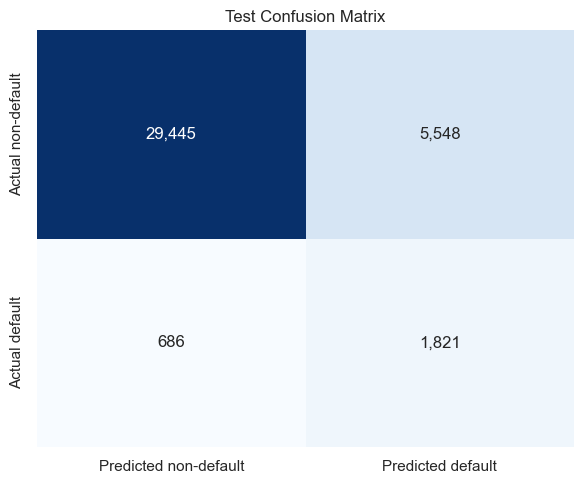

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix_df, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Test Confusion Matrix")
plt.tight_layout()


In [28]:
print(classification_report(y_test, test_pred, target_names=["Non-default", "Default"]))


              precision    recall  f1-score   support

 Non-default       0.98      0.84      0.90     34993
     Default       0.25      0.73      0.37      2507

    accuracy                           0.83     37500
   macro avg       0.61      0.78      0.64     37500
weighted avg       0.93      0.83      0.87     37500



## 12. Lift and Risk Ranking

Credit-risk models are often used to rank borrowers by risk. The lift table divides the test set into ten predicted-risk buckets and compares each bucket's observed default rate with the portfolio average. A strong model should concentrate defaults in the highest-risk buckets.

Because calibrated PD values can contain ties, the bucketing step ranks predictions first and then applies equal-frequency cuts. This keeps the table at ten buckets while preserving the ordering from highest to lowest predicted risk.

In [29]:
risk_ranking = pd.DataFrame({"y_true": y_test.values, "pd_score": test_score})
risk_ranking["risk_rank"] = risk_ranking["pd_score"].rank(method="first", ascending=False)
risk_ranking["risk_decile"] = pd.qcut(
    risk_ranking["risk_rank"],
    q=10,
    labels=range(1, 11),
).astype(int)

decile_summary = risk_ranking.groupby("risk_decile").agg(
    borrowers=("y_true", "size"),
    defaults=("y_true", "sum"),
    observed_default_rate=("y_true", "mean"),
    avg_pd_score=("pd_score", "mean"),
).reset_index()
decile_summary["lift_vs_portfolio"] = decile_summary["observed_default_rate"] / y_test.mean()
decile_summary

,risk_decile,borrowers,defaults,observed_default_rate,avg_pd_score,lift_vs_portfolio
0,1,3750,1387,0.3699,0.3703,5.5325
1,2,3750,445,0.1187,0.1198,1.7750
2,3,3750,244,0.0651,0.0670,0.9733
3,4,3750,151,0.0403,0.0429,0.6023
4,5,3750,95,0.0253,0.0258,0.3789
5,6,3750,67,0.0179,0.0141,0.2673
6,7,3750,53,0.0141,0.0106,0.2114
7,8,3750,29,0.0077,0.0089,0.1157
8,9,3750,23,0.0061,0.0056,0.0917
9,10,3750,13,0.0035,0.0023,0.0519


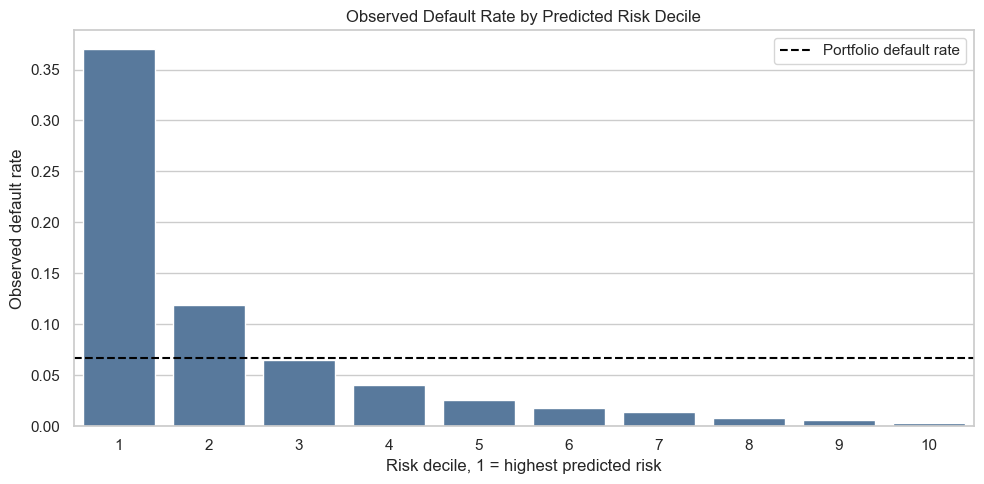

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=decile_summary, x="risk_decile", y="observed_default_rate", ax=ax, color="#4C78A8")
ax.axhline(y_test.mean(), color="black", linestyle="--", label="Portfolio default rate")
ax.set_title("Observed Default Rate by Predicted Risk Decile")
ax.set_xlabel("Risk decile, 1 = highest predicted risk")
ax.set_ylabel("Observed default rate")
ax.legend()
plt.tight_layout()


# Interpretation and Model Reporting

This stage explains model drivers, reviews segment behavior, and summarizes the recommended model in a model-card format.


## 13. Model Interpretation

The final model is interpreted with permutation importance on a validation sample. This estimates how much PR-AUC declines when each raw feature is shuffled. It is a model-agnostic way to identify important risk drivers.

For production-grade explainability, SHAP values and stability checks across time or population slices would be stronger.


In [31]:
def get_processed_feature_names(pipeline):
    prep = pipeline.named_steps["prep"]
    return prep.get_feature_names_out()

if selected_model_name == "Logistic Regression":
    feature_names = get_processed_feature_names(selected_model)
    coefs = selected_model.named_steps["model"].coef_[0]
    interpretation = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs),
    }).sort_values("abs_coefficient", ascending=False)
elif selected_model_name == "Random Forest":
    feature_names = get_processed_feature_names(selected_model)
    importances = selected_model.named_steps["model"].feature_importances_
    interpretation = pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    }).sort_values("importance", ascending=False)
else:
    X_valid_sample = X_valid.sample(n=min(10000, len(X_valid)), random_state=RANDOM_STATE)
    y_valid_sample = y_valid.loc[X_valid_sample.index]
    perm = permutation_importance(
        selected_model,
        X_valid_sample,
        y_valid_sample,
        scoring="average_precision",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    interpretation = pd.DataFrame({
        "feature": X_valid.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

interpretation.head(15)


,feature,importance
0,RevolvingUtilizationOfUnsecuredLines,0.2455
12,DelinquencyCountTotal,0.1891
13,AnyDelinquency,0.1532
2,NumberOfTime30-59DaysPastDueNotWorse,0.0607
6,NumberOfTimes90DaysLate,0.0578
14,SevereDelinquency,0.0525
1,age,0.0406
8,NumberOfTime60-89DaysPastDueNotWorse,0.0314
3,DebtRatio,0.0294
16,DebtPerIncome,0.0262


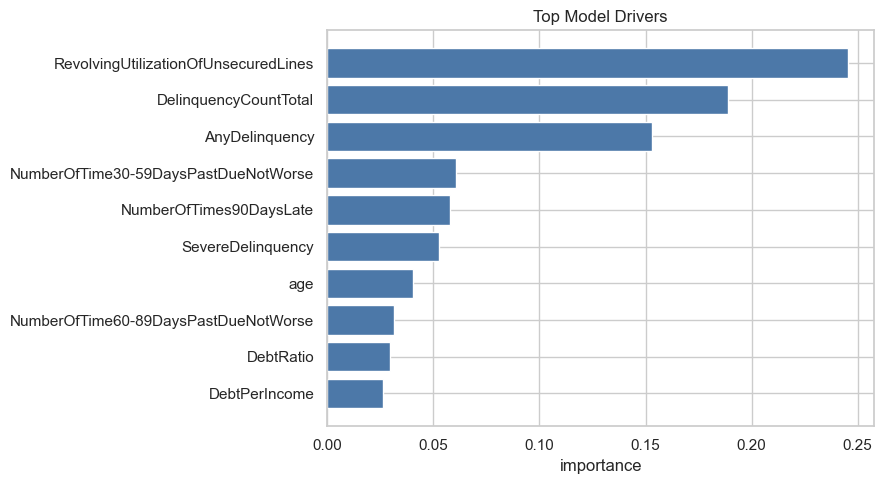

In [32]:
importance_col = "importance_mean" if "importance_mean" in interpretation.columns else (
    "importance" if "importance" in interpretation.columns else "abs_coefficient"
)

plot_importance = interpretation.head(10).sort_values(importance_col, ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_importance["feature"], plot_importance[importance_col], color="#4C78A8")
ax.set_title("Top Model Drivers")
ax.set_xlabel(importance_col)
plt.tight_layout()


## 13.1 SHAP Explanation

SHAP values provide a more direct view of how individual features push predicted risk higher or lower. The charts below explain the selected model on a validation sample after applying the same preprocessing pipeline used during training. The SHAP analysis is based on the selected uncalibrated model because calibration changes probability scaling, not the underlying feature-ranking logic.


In [33]:
X_shap_raw = X_valid.sample(n=min(1000, len(X_valid)), random_state=RANDOM_STATE)

pre_model_pipeline = selected_model[:-1]
selected_estimator = selected_model.named_steps["model"]
X_shap_processed = pre_model_pipeline.transform(X_shap_raw)
processed_feature_names = selected_model.named_steps["prep"].get_feature_names_out()
X_shap_processed = pd.DataFrame(X_shap_processed, columns=processed_feature_names, index=X_shap_raw.index)

explainer = shap.TreeExplainer(selected_estimator)
shap_values_raw = explainer.shap_values(X_shap_processed)

if isinstance(shap_values_raw, list):
    shap_values_for_default = shap_values_raw[1]
elif getattr(shap_values_raw, "ndim", None) == 3:
    shap_values_for_default = shap_values_raw[:, :, 1]
else:
    shap_values_for_default = shap_values_raw

shap_importance = pd.DataFrame({
    "feature": processed_feature_names,
    "mean_abs_shap": np.abs(shap_values_for_default).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
shap_importance.head(15)


,feature,mean_abs_shap
0,RevolvingUtilizationOfUnsecuredLines,0.1202
12,DelinquencyCountTotal,0.0695
13,AnyDelinquency,0.0569
1,age,0.0296
6,NumberOfTimes90DaysLate,0.0228
14,SevereDelinquency,0.0202
2,NumberOfTime30-59DaysPastDueNotWorse,0.0193
8,NumberOfTime60-89DaysPastDueNotWorse,0.0142
3,DebtRatio,0.0136
5,NumberOfOpenCreditLinesAndLoans,0.0108


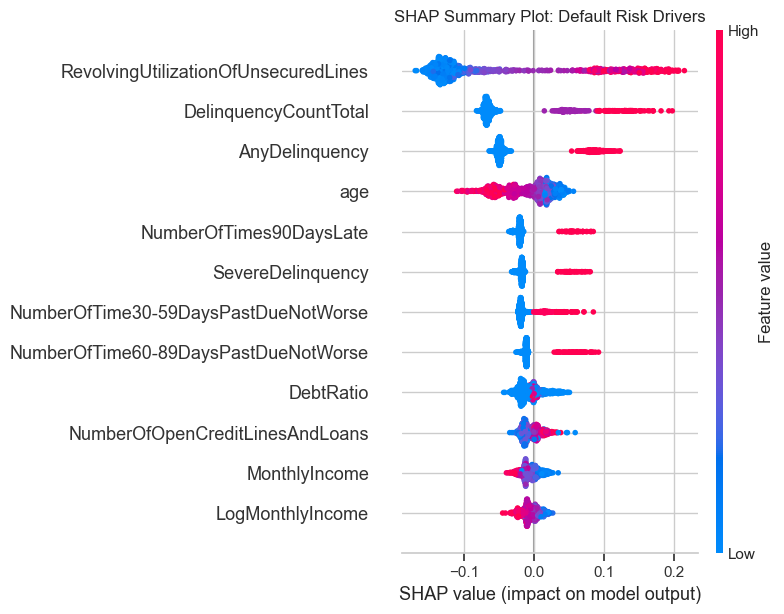

In [34]:
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values_for_default,
    X_shap_processed,
    max_display=12,
    show=False,
)
plt.title("SHAP Summary Plot: Default Risk Drivers")
plt.tight_layout()


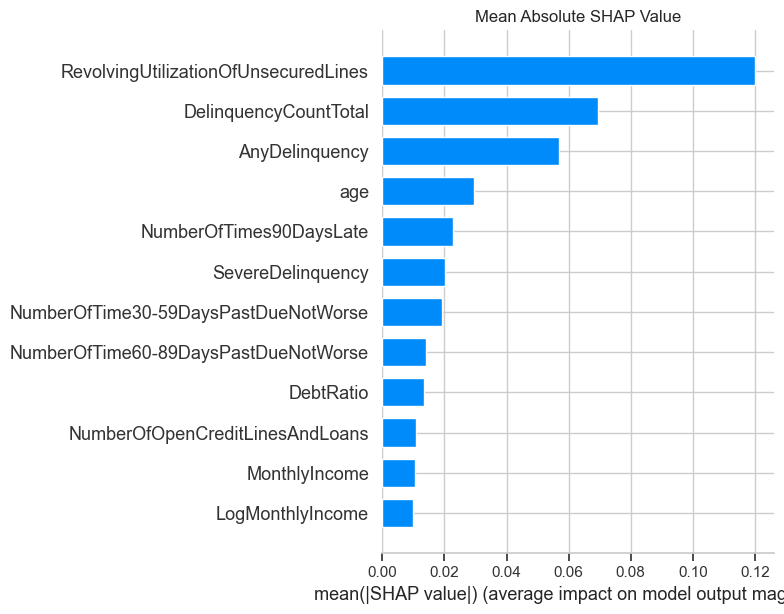

In [35]:
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values_for_default,
    X_shap_processed,
    plot_type="bar",
    max_display=12,
    show=False,
)
plt.title("Mean Absolute SHAP Value")
plt.tight_layout()


## 14. Segment Performance Review

A final credit-risk model should be checked across meaningful borrower segments, not only at the portfolio level. This section reviews test-set performance by age band, income missingness, and prior delinquency history. The goal is to identify whether performance is concentrated in only one segment or remains directionally consistent across groups.


In [36]:
segment_frame = X_test.copy()
segment_frame["y_true"] = y_test.values
segment_frame["pd_score"] = test_score
segment_frame["y_pred"] = test_pred
segment_frame["age_band"] = pd.cut(
    segment_frame["age"],
    bins=[17, 30, 45, 60, 120],
    labels=["18-30", "31-45", "46-60", "61+"],
)
segment_frame["income_missing"] = np.where(segment_frame["MonthlyIncome"].isna(), "missing", "observed")
segment_frame["prior_delinquency"] = np.where(
    segment_frame[[
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
    ]].sum(axis=1) > 0,
    "any_prior_delinquency",
    "no_prior_delinquency",
)

def segment_metrics(frame, segment_col):
    rows = []
    for value, g in frame.groupby(segment_col, observed=False):
        if len(g) == 0:
            continue
        rows.append({
            "segment_type": segment_col,
            "segment": str(value),
            "borrowers": len(g),
            "default_rate": g["y_true"].mean(),
            "avg_pd_score": g["pd_score"].mean(),
            "flagged_rate": g["y_pred"].mean(),
            "precision": precision_score(g["y_true"], g["y_pred"], zero_division=0),
            "recall": recall_score(g["y_true"], g["y_pred"], zero_division=0),
        })
    return pd.DataFrame(rows)

segment_review = pd.concat([
    segment_metrics(segment_frame, "age_band"),
    segment_metrics(segment_frame, "income_missing"),
    segment_metrics(segment_frame, "prior_delinquency"),
], ignore_index=True)
segment_review


,segment_type,segment,borrowers,default_rate,avg_pd_score,flagged_rate,precision,recall
0,age_band,18-30,2683,0.1234,0.1132,0.3817,0.2676,0.8278
1,age_band,31-45,10196,0.0959,0.0944,0.2892,0.2540,0.7658
2,age_band,46-60,13341,0.0665,0.0673,0.1927,0.2408,0.6979
3,age_band,61+,11280,0.0276,0.0300,0.0731,0.2170,0.5756
4,income_missing,missing,7511,0.0586,0.0577,0.1583,0.2826,0.7636
5,income_missing,observed,29989,0.0689,0.0690,0.2061,0.2403,0.7184
6,prior_delinquency,any_prior_delinquency,7511,0.2271,0.2268,0.7130,0.2951,0.9261
7,prior_delinquency,no_prior_delinquency,29989,0.0267,0.0266,0.0672,0.1197,0.3009


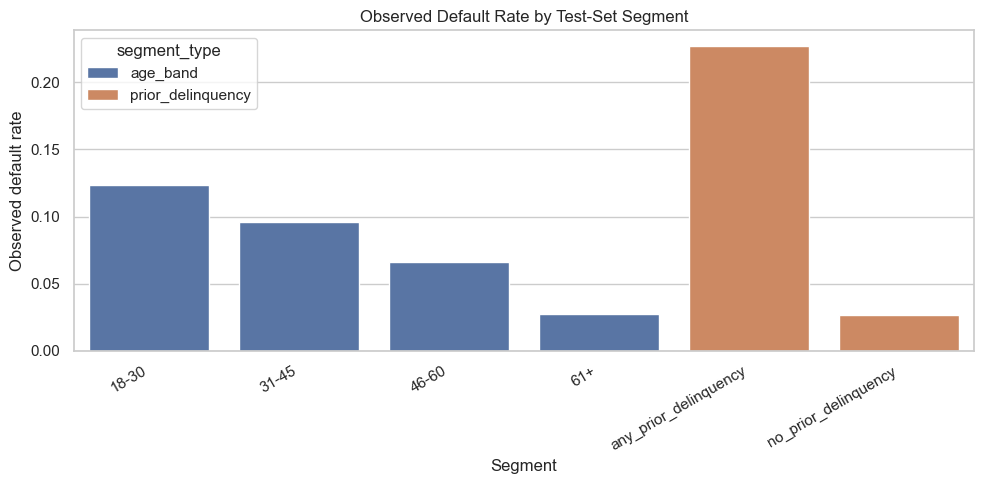

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_segments = segment_review[segment_review["segment_type"].isin(["age_band", "prior_delinquency"])]
sns.barplot(data=plot_segments, x="segment", y="default_rate", hue="segment_type", ax=ax)
ax.set_title("Observed Default Rate by Test-Set Segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Observed default rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()


## 14.1 High-Risk Decile Segment Deep Dive

The highest-risk decile is the most important group for credit review because it concentrates the largest share of predicted default risk. This subsection profiles that group by income missingness, age band, and prior delinquency history to check whether the high-risk segment is driven by recognizable credit-risk patterns.


In [38]:
high_risk_decile = int(decile_summary["risk_decile"].min())
high_risk_frame = segment_frame.loc[risk_ranking["risk_decile"].values == high_risk_decile].copy()

high_risk_segment_review = pd.concat([
    segment_metrics(high_risk_frame, "age_band"),
    segment_metrics(high_risk_frame, "income_missing"),
    segment_metrics(high_risk_frame, "prior_delinquency"),
], ignore_index=True)
high_risk_segment_review


,segment_type,segment,borrowers,default_rate,avg_pd_score,flagged_rate,precision,recall
0,age_band,18-30,504,0.4167,0.3724,1.0000,0.4167,1.0000
1,age_band,31-45,1531,0.3769,0.3761,1.0000,0.3769,1.0000
2,age_band,46-60,1317,0.3576,0.3677,1.0000,0.3576,1.0000
3,age_band,61+,398,0.3241,0.3532,1.0000,0.3241,1.0000
4,income_missing,missing,685,0.3883,0.3946,1.0000,0.3883,1.0000
5,income_missing,observed,3065,0.3657,0.3648,1.0000,0.3657,1.0000
6,prior_delinquency,any_prior_delinquency,3636,0.3740,0.3755,1.0000,0.3740,1.0000
7,prior_delinquency,no_prior_delinquency,114,0.2368,0.2044,1.0000,0.2368,1.0000


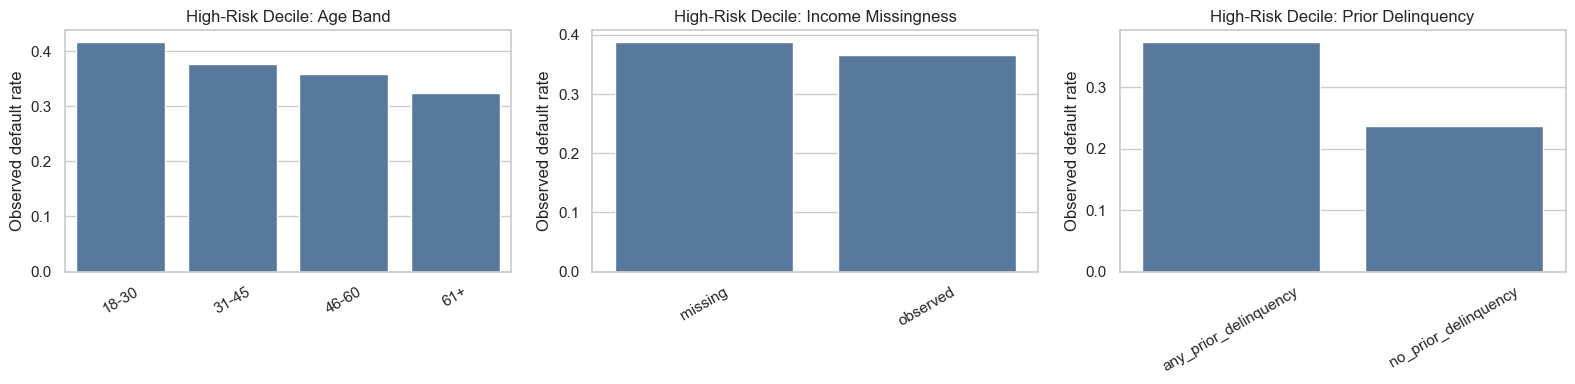

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, segment_col, title in [
    (axes[0], "age_band", "Age Band"),
    (axes[1], "income_missing", "Income Missingness"),
    (axes[2], "prior_delinquency", "Prior Delinquency"),
]:
    plot_data = high_risk_segment_review[high_risk_segment_review["segment_type"] == segment_col]
    sns.barplot(data=plot_data, x="segment", y="default_rate", ax=ax, color="#4C78A8")
    ax.set_title(f"High-Risk Decile: {title}")
    ax.set_xlabel("")
    ax.set_ylabel("Observed default rate")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()


## 15. Final Model Assessment and Recommendation

The recommended model is the candidate with the strongest validation PR-AUC, then calibrated and evaluated on the held-out test set. Logistic Regression remains useful as an interpretable benchmark, but the selected gradient boosting model is preferred because it better captures nonlinear tabular risk patterns and produces stronger minority-class ranking performance.

The final decision threshold is not chosen by default probability cutoff. It is chosen through an illustrative business-cost rule where false negatives are treated as more expensive than false positives. This makes the final classifier more focused on catching default risk, which is typical in risk-screening contexts.

The lift table is especially important: if the highest-risk decile has a much higher observed default rate than the portfolio average, the model is useful for risk ranking even when precision at a policy threshold is modest.


In [40]:
final_summary = pd.DataFrame([{
    "recommended_model": selected_model_name,
    "test_roc_auc": test_metrics.loc[0, "roc_auc"],
    "test_pr_auc": test_metrics.loc[0, "pr_auc"],
    "test_brier": test_metrics.loc[0, "brier"],
    "selected_threshold": selected_threshold,
    "test_precision": test_metrics.loc[0, "precision"],
    "test_recall": test_metrics.loc[0, "recall"],
    "test_f1": test_metrics.loc[0, "f1"],
    "highest_risk_decile_default_rate": decile_summary.loc[decile_summary["risk_decile"] == 1, "observed_default_rate"].iloc[0],
    "highest_risk_decile_lift": decile_summary.loc[decile_summary["risk_decile"] == 1, "lift_vs_portfolio"].iloc[0],
}])
final_summary


,recommended_model,test_roc_auc,test_pr_auc,test_brier,selected_threshold,test_precision,test_recall,test_f1,highest_risk_decile_default_rate,highest_risk_decile_lift
0,Random Forest,0.8655,0.3776,0.0493,0.0900,0.2471,0.7264,0.3688,0.3699,5.5325


## 16. Model Card

The model card summarizes the intended use, data, selected model, metrics, threshold policy, interpretability approach, and scope boundaries in a compact format.


In [41]:
model_card = pd.DataFrame([
    {"field": "Intended use", "description": "Rank borrowers by probability of serious delinquency and support credit-risk review decisions."},
    {"field": "Target", "description": "SeriousDlqin2yrs: 90+ days past-due delinquency or worse within two years."},
    {"field": "Data", "description": f"{len(model_df):,} borrower records after removing invalid ages; local CSV source."},
    {"field": "Recommended model", "description": selected_model_name},
    {"field": "Model selection metric", "description": "Validation PR-AUC, selected on model-validation set."},
    {"field": "Calibration", "description": "Isotonic calibration fitted on a separate calibration/policy set."},
    {"field": "Threshold policy", "description": f"Threshold {selected_threshold:.2f}, selected by illustrative FN:FP cost ratio of 10:1."},
    {"field": "Test ROC-AUC", "description": f"{test_metrics.loc[0, 'roc_auc']:.4f}"},
    {"field": "Test PR-AUC", "description": f"{test_metrics.loc[0, 'pr_auc']:.4f}"},
    {"field": "Test recall", "description": f"{test_metrics.loc[0, 'recall']:.4f}"},
    {"field": "High-risk decile lift", "description": f"{decile_summary.loc[decile_summary['risk_decile'] == 1, 'lift_vs_portfolio'].iloc[0]:.2f}x"},
    {"field": "Interpretability", "description": "Feature importance and SHAP explanations on a validation sample."},
    {"field": "Fairness and compliance", "description": "Segment checks are diagnostic only; this is not a full fair-lending, adverse-action, or regulatory validation review."},
    {"field": "Scope boundary", "description": "No loan economics, reject-inference data, protected attributes, or timestamps are available in the dataset."},
])
model_card

,field,description
0,Intended use,Rank borrowers by probability of serious delin...
1,Target,SeriousDlqin2yrs: 90+ days past-due delinquenc...
2,Data,"149,999 borrower records after removing invali..."
3,Recommended model,Random Forest
4,Model selection metric,"Validation PR-AUC, selected on model-validatio..."
5,Calibration,Isotonic calibration fitted on a separate cali...
6,Threshold policy,"Threshold 0.09, selected by illustrative FN:FP..."
7,Test ROC-AUC,0.8655
8,Test PR-AUC,0.3776
9,Test recall,0.7264


## 17. Model Scope

The final model provides a complete probability-of-default workflow for the available borrower-level dataset. It supports risk ranking, calibrated PD estimation, threshold-based classification, segment-level performance review, and model interpretation.

The analysis is limited to the variables available in the dataset. Portfolio-specific economics such as loan amount, interest income, loss given default, exposure at default, and operational review cost are not included, so threshold costs are treated as configurable assumptions rather than fixed business values. The dataset also does not include application decision history or timestamps, so reject-inference and time-based monitoring are outside the scope of this analysis.

The segment review checks model behavior across age bands, income missingness, and delinquency history, but it is not a full fairness audit. A production credit decisioning model would require governance review, fair-lending analysis, adverse-action reason validation, monitoring controls, and approval from the relevant risk and compliance stakeholders.

## 18. Credit Risk Scoring Mechanism

The calibrated PD model is converted into a business-readable credit risk score. The score follows the traditional log-odds scorecard convention: higher scores indicate lower default risk, and a fixed Points to Double the Odds (PDO) controls how quickly the score changes as borrower odds improve.

This section adds four practical scoring outputs:

1. A PD-to-score transformation with an inverse score-to-PD check.
2. A score distribution and score cutoff corresponding to the selected PD threshold.
3. A-E risk grades with observed default rates on the held-out test set.
4. Example borrower PDs to test monotonicity, grade assignment, and policy actions.

In [42]:
SCORING_CONFIG = {
    "base_score": 600,
    "base_odds": 20,
    "pdo": 50,
    "min_score": 300,
    "max_score": 850,
}

RISK_GRADE_BINS = [-np.inf, 540, 600, 660, 720, np.inf]
RISK_GRADE_LABELS = ["E", "D", "C", "B", "A"]
RISK_GRADE_ACTIONS = {
    "A": "Auto approve / best terms",
    "B": "Approve / standard terms",
    "C": "Approve with review or lower limit",
    "D": "Manual review / risk-based pricing",
    "E": "Decline or enhanced verification",
}


def score_from_pd(pd_values, config=SCORING_CONFIG):
    """Convert calibrated probability of default into a bounded credit risk score."""
    pd_array = np.asarray(pd_values, dtype=float)
    pd_array = np.clip(pd_array, 1e-6, 1 - 1e-6)
    factor = config["pdo"] / np.log(2)
    offset = config["base_score"] - factor * np.log(config["base_odds"])
    odds = (1 - pd_array) / pd_array
    score = offset + factor * np.log(odds)
    return np.clip(score, config["min_score"], config["max_score"])


def pd_from_score(scores, config=SCORING_CONFIG):
    """Invert the score transformation back to an implied PD before score clipping."""
    score_array = np.asarray(scores, dtype=float)
    factor = config["pdo"] / np.log(2)
    offset = config["base_score"] - factor * np.log(config["base_odds"])
    odds = np.exp((score_array - offset) / factor)
    return 1 / (1 + odds)


def assign_risk_grade(scores):
    return pd.cut(
        pd.Series(scores),
        bins=RISK_GRADE_BINS,
        labels=RISK_GRADE_LABELS,
        right=False,
        ordered=True,
    )


selected_score_cutoff = float(score_from_pd([selected_threshold])[0])

scoring_policy = pd.DataFrame([
    {
        "risk_grade": "A",
        "score_range": "720+",
        "risk_level": "Very low",
        "recommended_action": RISK_GRADE_ACTIONS["A"],
    },
    {
        "risk_grade": "B",
        "score_range": "660-719",
        "risk_level": "Low",
        "recommended_action": RISK_GRADE_ACTIONS["B"],
    },
    {
        "risk_grade": "C",
        "score_range": "600-659",
        "risk_level": "Medium",
        "recommended_action": RISK_GRADE_ACTIONS["C"],
    },
    {
        "risk_grade": "D",
        "score_range": "540-599",
        "risk_level": "High",
        "recommended_action": RISK_GRADE_ACTIONS["D"],
    },
    {
        "risk_grade": "E",
        "score_range": "<540",
        "risk_level": "Very high",
        "recommended_action": RISK_GRADE_ACTIONS["E"],
    },
])

pd.DataFrame([{
    "base_score": SCORING_CONFIG["base_score"],
    "base_odds_good_to_bad": f"{SCORING_CONFIG['base_odds']}:1",
    "pdo": SCORING_CONFIG["pdo"],
    "score_floor": SCORING_CONFIG["min_score"],
    "score_cap": SCORING_CONFIG["max_score"],
    "selected_pd_threshold": selected_threshold,
    "equivalent_score_cutoff": selected_score_cutoff,
}])

,base_score,base_odds_good_to_bad,pdo,score_floor,score_cap,selected_pd_threshold,equivalent_score_cutoff
0,600,20:1,50,300,850,0.0900,550.7971


In [43]:
score_frame = pd.DataFrame({
    "y_true": y_test.values,
    "pd_score": test_score,
})
score_frame["credit_score"] = score_from_pd(score_frame["pd_score"])
score_frame["risk_grade"] = assign_risk_grade(score_frame["credit_score"]).values
score_frame["recommended_action"] = score_frame["risk_grade"].astype(str).map(RISK_GRADE_ACTIONS)
score_frame["below_policy_cutoff"] = score_frame["credit_score"] <= selected_score_cutoff

grade_summary = score_frame.groupby("risk_grade", observed=False).agg(
    borrowers=("y_true", "size"),
    borrower_share=("y_true", lambda s: len(s) / len(score_frame)),
    defaults=("y_true", "sum"),
    observed_default_rate=("y_true", "mean"),
    avg_pd=("pd_score", "mean"),
    min_score=("credit_score", "min"),
    avg_score=("credit_score", "mean"),
    max_score=("credit_score", "max"),
).reset_index()

grade_summary["lift_vs_portfolio"] = grade_summary["observed_default_rate"] / y_test.mean()
grade_summary = grade_summary.merge(scoring_policy, on="risk_grade", how="left")
grade_summary[[
    "risk_grade",
    "score_range",
    "borrowers",
    "borrower_share",
    "observed_default_rate",
    "avg_pd",
    "avg_score",
    "lift_vs_portfolio",
    "recommended_action",
]]

,risk_grade,score_range,borrowers,borrower_share,observed_default_rate,avg_pd,avg_score,lift_vs_portfolio,recommended_action
0,E,<540,6363,0.1697,0.2709,0.2714,465.1186,4.0528,Decline or enhanced verification
1,D,540-599,5185,0.1383,0.0708,0.0727,569.8539,1.0588,Manual review / risk-based pricing
2,C,600-659,7440,0.1984,0.0320,0.0333,630.5102,0.4785,Approve with review or lower limit
3,B,660-719,9212,0.2457,0.0141,0.0117,705.0979,0.2111,Approve / standard terms
4,A,720+,9300,0.2480,0.0052,0.0046,781.3579,0.0772,Auto approve / best terms


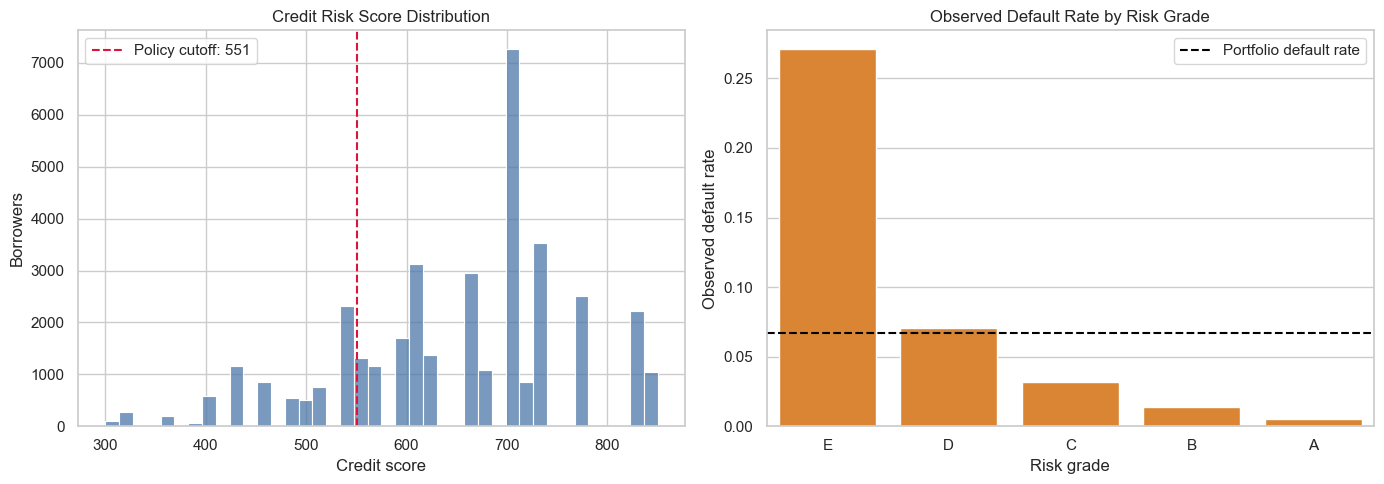

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(score_frame["credit_score"], bins=40, ax=axes[0], color="#4C78A8")
axes[0].axvline(selected_score_cutoff, color="crimson", linestyle="--", label=f"Policy cutoff: {selected_score_cutoff:.0f}")
axes[0].set_title("Credit Risk Score Distribution")
axes[0].set_xlabel("Credit score")
axes[0].set_ylabel("Borrowers")
axes[0].legend()

sns.barplot(data=grade_summary, x="risk_grade", y="observed_default_rate", ax=axes[1], color="#F58518")
axes[1].axhline(y_test.mean(), color="black", linestyle="--", label="Portfolio default rate")
axes[1].set_title("Observed Default Rate by Risk Grade")
axes[1].set_xlabel("Risk grade")
axes[1].set_ylabel("Observed default rate")
axes[1].legend()

plt.tight_layout()

### 18.1 Example Score Tests

The examples below use representative calibrated PD values rather than real borrower records. They test whether the scoring mechanism behaves as expected: higher PD should produce a lower score, the score should map into a risk grade, and the selected policy PD threshold should have an equivalent score cutoff.

In [45]:
example_pd_values = np.array([0.01, 0.03, 0.06, selected_threshold, 0.15, 0.30])
example_scores = score_from_pd(example_pd_values)
example_grades = assign_risk_grade(example_scores)

example_score_tests = pd.DataFrame({
    "example": ["Very low PD", "Low PD", "Moderate PD", "Policy threshold", "High PD", "Very high PD"],
    "calibrated_pd": example_pd_values,
    "credit_score": example_scores,
    "risk_grade": example_grades.astype(str).values,
})
example_score_tests["implied_pd_from_score"] = pd_from_score(example_score_tests["credit_score"])
example_score_tests["recommended_action"] = example_score_tests["risk_grade"].map(RISK_GRADE_ACTIONS)
example_score_tests

,example,calibrated_pd,credit_score,risk_grade,implied_pd_from_score,recommended_action
0,Very low PD,0.0100,715.3714,B,0.0100,Approve / standard terms
1,Low PD,0.0300,634.6511,C,0.0300,Approve with review or lower limit
2,Moderate PD,0.0600,582.3849,D,0.0600,Manual review / risk-based pricing
3,Policy threshold,0.0900,550.7971,D,0.0900,Manual review / risk-based pricing
4,High PD,0.1500,509.0286,E,0.1500,Decline or enhanced verification
5,Very high PD,0.3000,445.0232,E,0.3000,Decline or enhanced verification


In [46]:
# Scoring mechanism sanity checks.
monotonic_pd_values = np.array([0.01, 0.03, 0.06, 0.09, 0.15, 0.30])
monotonic_scores = score_from_pd(monotonic_pd_values)
assert np.all(np.diff(monotonic_scores) < 0), "Credit score should decrease as PD increases."

roundtrip_pd_values = np.array([0.01, 0.03, 0.06, 0.09, 0.15, 0.30])
roundtrip_scores = score_from_pd(roundtrip_pd_values)
assert np.allclose(pd_from_score(roundtrip_scores), roundtrip_pd_values, atol=1e-10), "Score-to-PD inverse check failed."

assert score_frame["risk_grade"].notna().all(), "Every scored borrower should receive a risk grade."
assert grade_summary["observed_default_rate"].is_monotonic_decreasing, "Default rate should decline from E to A in this test sample."

pd.DataFrame([{
    "test": "scoring_sanity_checks",
    "status": "passed",
    "examples_checked": len(example_score_tests),
    "test_borrowers_scored": len(score_frame),
    "policy_pd_threshold": selected_threshold,
    "policy_score_cutoff": selected_score_cutoff,
}])

,test,status,examples_checked,test_borrowers_scored,policy_pd_threshold,policy_score_cutoff
0,scoring_sanity_checks,passed,6,37500,0.0900,550.7971


### 18.2 Scoring Policy Summary

The score should be interpreted as a risk-ranking and policy-support layer on top of the calibrated PD model. The exact approval action and score cutoffs should be adjusted if real loan economics, exposure, pricing, or operational review capacity become available.

In [47]:
scoring_card = pd.DataFrame([
    {"field": "Score direction", "description": "Higher score means lower predicted default risk."},
    {"field": "Score formula", "description": "Log-odds scorecard mapping from calibrated PD."},
    {"field": "Base point", "description": f"Score {SCORING_CONFIG['base_score']} corresponds to good:bad odds of {SCORING_CONFIG['base_odds']}:1."},
    {"field": "PDO", "description": f"Every odds doubling increases the score by {SCORING_CONFIG['pdo']} points."},
    {"field": "Score range", "description": f"Scores are clipped to {SCORING_CONFIG['min_score']}-{SCORING_CONFIG['max_score']} for business readability."},
    {"field": "Policy cutoff", "description": f"The selected PD threshold of {selected_threshold:.2f} maps to a score cutoff of {selected_score_cutoff:.1f}."},
    {"field": "Risk grades", "description": "A=very low risk, B=low risk, C=medium risk, D=high risk, E=very high risk."},
    {"field": "Use boundary", "description": "The score is model-based and should not be treated as a bureau credit score or a regulated production scorecard without governance review."},
])
scoring_card

,field,description
0,Score direction,Higher score means lower predicted default risk.
1,Score formula,Log-odds scorecard mapping from calibrated PD.
2,Base point,Score 600 corresponds to good:bad odds of 20:1.
3,PDO,Every odds doubling increases the score by 50 ...
4,Score range,Scores are clipped to 300-850 for business rea...
5,Policy cutoff,The selected PD threshold of 0.09 maps to a sc...
6,Risk grades,"A=very low risk, B=low risk, C=medium risk, D=..."
7,Use boundary,The score is model-based and should not be tre...


## 19. Limitations and Next Steps

This notebook is a complete analytical project artifact, but a production credit decisioning model would need additional validation before use:

- Validate the policy threshold with real lending economics such as exposure, loss severity, pricing, and manual-review capacity.
- Monitor calibration, score distribution, feature missingness, and default-rate drift after deployment.
- Run fair-lending, compliance, and adverse-action reason review before using the model for regulated decisions.
- Keep notebook logic aligned with the reusable `src/` package and `scripts/` pipeline to avoid implementation drift.